## Customer Churn & Revenue Exposure Analytics

#### 1. Import Libraries

In [1]:
# import libraries
import os
from sqlalchemy import create_engine
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance

#### 2. Connect to Database

In [2]:
load_dotenv()
db_url = os.getenv("DATABASE_URL")

if db_url is None:
    print("Cant find the database URL.")
else:
    engine = create_engine(db_url)
    print("Successfully connected to the database!")



df = pd.read_sql(
    "SELECT * FROM churn_cleaned",
    engine
)

Successfully connected to the database!


#### 3. Validate and Preview Cleaned Data

In [3]:
# exploaration and cleaning done in SQL
# check the loaded data is correct.
print("Rows:", df.shape[0])
print("Duplicate customers:", df["customer_id"].duplicated().sum())
print("Missing total charges:", df["total_charges"].isna().sum())

overall_churn = df["churn_flag"].mean() * 100
print(f"Overall churn rate: {overall_churn:.2f}%")

Rows: 7043
Duplicate customers: 0
Missing total charges: 0
Overall churn rate: 26.54%


In [4]:
# see top 5 rows of the dataframe
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn,churn_flag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


#### 4. Create Tenure Segments

In [5]:
# Create tenure categories for analysis
df["tenure_segment"] = pd.cut(
    df["tenure"],
    bins=[-1,12,36,100],
    labels=[
        "New Customer",
        "Existing Customer",
        "Loyal Customer"
    ]
)

#### 5. Main Factor Screening

All 17 customer attributes were compared using the same measures: customer count, churned customers, churn rate, churn lift versus the overall churn rate, active customers, active monthly revenue, and estimated monthly revenue exposure. 

The overall churn rate (26.5%) is used as a company-level reference. Category sizes were checked to avoid unreliable comparisons from very small groups. Exposure is evaluated separately for each factor and are not added across factors, because customer groups can overlap.

##### 5.1 Define Segment Analysis Function

In [6]:
def segment_risk_analysis(data, segment_column):

    result = (
        data.groupby(segment_column, observed=False)
        .agg(
            total_customers=("customer_id", "count"),
            churned_customers=("churn_flag", "sum"),
            churn_rate=("churn_flag", "mean")
        )
        .reset_index()
    )

    # Calculate active customers and revenue
    active = (
        data[data["churn"] == "No"]
        .groupby(segment_column, observed=False)
        .agg(
            active_customers=("customer_id", "count"),
            active_monthly_revenue=("monthly_charges", "sum")
        )
        .reset_index()
    )

    result = result.merge(
        active,
        on=segment_column,
        how="left"
    )

    # Convert churn rate to percenatge and round to 2 decimal places
    result["churn_rate"] = (
        result["churn_rate"] * 100
    ).round(2)

    # Estimate potential monthly revenue exposure
    result["estimated_monthly_revenue_exposure"] = (
        result["active_monthly_revenue"]
        *
        result["churn_rate"]
        /
        100
    )

    return result

##### 5.2 Analyze Customer Segments

In [7]:
# Map dimension names to DataFrame columns
dimensions = {
    "Gender": "gender",
    "Senior Citizen": "senior_citizen",
    "Partner": "partner",
    "Dependents": "dependents",
    "Phone Service": "phone_service",
    "Multiple Lines": "multiple_lines",
    "Internet Service": "internet_service",
    "Online Security": "online_security",
    "Online Backup": "online_backup",
    "Device Protection": "device_protection",
    "Tech Support": "tech_support",
    "Streaming TV": "streaming_tv",
    "Streaming Movies": "streaming_movies",
    "Contract Type": "contract",
    "Paperless Billing": "paperless_billing",
    "Payment Behaviour": "payment_method",
    "Tenure": "tenure_segment"
}

In [25]:
all_results = []

for dimension_name, column_name in dimensions.items():

    result = segment_risk_analysis(
        df,
        column_name
    )

    result.insert(
        0,
        "dimension",
        dimension_name
    )

    result = result.rename(
        columns={
            column_name: "category"
        }
    )

    all_results.append(result)


# Combine and sort results from all dimensions
factor_analysis = pd.concat(
    all_results,
    ignore_index=True
)

# Lift versus the overall churn rate (1.0 = same as company average)
factor_analysis["lift_vs_overall"] = (factor_analysis["churn_rate"] / overall_churn).round(2)

factor_analysis = factor_analysis.sort_values(
    "estimated_monthly_revenue_exposure",
    ascending=False
).reset_index(drop=True)

factor_analysis_df = pd.DataFrame(
    factor_analysis[
        [
            "dimension",
            "category",
            "total_customers",
            "churned_customers",
            "churn_rate",
            "lift_vs_overall",
            "active_customers",
            "active_monthly_revenue",
            "estimated_monthly_revenue_exposure"
        ]
    ]
)

factor_analysis_df

,dimension,category,total_customers,churned_customers,churn_rate,lift_vs_overall,active_customers,active_monthly_revenue,estimated_monthly_revenue_exposure
0,Phone Service,Yes,6361,1699,26.71,1.01,4662,294703.00,78715.171300
1,Internet Service,Fiber optic,3096,1297,41.89,1.58,1799,168984.35,70787.544215
2,Dependents,No,4933,1543,31.28,1.18,3390,215148.35,67298.403880
3,Paperless Billing,Yes,4171,1400,33.57,1.27,2771,197282.80,66227.835960
4,Online Security,No,3498,1461,41.77,1.57,2037,152011.60,63495.245320
5,Senior Citizen,0,5901,1393,23.61,0.89,4508,264250.50,62389.543050
6,Tech Support,No,3473,1446,41.64,1.57,2027,148329.75,61764.507900
7,Contract Type,Month-to-month,3875,1655,42.71,1.61,2220,136447.05,58276.535055
8,Online Backup,No,3088,1233,39.93,1.50,1855,130270.70,52017.090510
9,Device Protection,No,3095,1211,39.13,1.47,1884,129758.00,50774.305400


##### 5.3 Check Minimum Customer Group Sizes

In [26]:
# Check smallest overall customer group
print("\nSmallest total customer group:",
      factor_analysis["total_customers"].min())

# Check smallest active customer group, to ensure revenue exposure is not driven by tiny groups
print("Smallest active customer group:",
      factor_analysis["active_customers"].min())


Smallest total customer group: 682
Smallest active customer group: 512


#### 6. Main Factor Selection

1. **Group** the 17 attributes by business area: Contract & Lifecycle, Service & Product, Billing & Payment, and Customer Profile.
2. **Check every factor:**
   - **Group size:** categories need at least 100 customers (the smallest here has 682).
   - **Churn gap:** highest minus lowest category churn rate (cutoff: 30 points).
   - **Revenue exposure:** highest category exposure (cutoff: $40K).
3. **Cross-check** the ranking with Cramér's V and a logistic regression.
4. **Choose one factor per business area** with a strong churn gap, material exposure, and an action the company can take.

##### 6.1 Business Factor Grouping

In [9]:
# Group customer factors into business categories
factor_groups = pd.DataFrame({
    "Business Category": [
        "Contract & Lifecycle",
        "Service & Product",
        "Billing & Payment",
        "Customer Profile"
    ],
    "Factors": [
        "Contract Type, Tenure",
        "Internet Service, Online Security, Tech Support, Online Backup, Device Protection, Streaming Movies, Streaming TV, Phone Service, Multiple Lines",
        "Payment Behaviour, Paperless Billing",
        "Gender, Senior Citizen, Partner, Dependents"
    ]
})

factor_groups.style \
    .set_properties(**{
        "text-align": "left",
        "vertical-align": "top"
    }) \
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "left"),
                ("font-weight", "bold")
            ]
        },
        {
            "selector": "td:first-child",
            "props": [
                ("font-weight", "bold")
            ]
        }
    ])

,Business Category,Factors
0,Contract & Lifecycle,"Contract Type, Tenure"
1,Service & Product,"Internet Service, Online Security, Tech Support, Online Backup, Device Protection, Streaming Movies, Streaming TV, Phone Service, Multiple Lines"
2,Billing & Payment,"Payment Behaviour, Paperless Billing"
3,Customer Profile,"Gender, Senior Citizen, Partner, Dependents"


##### 6.2 Revenue Exposure and Churn spread screening

In [10]:
# Summarise the range of churn and highest exposure for each factor
dimension_summary = (
    factor_analysis
    .groupby("dimension", observed=True)
    .agg(
        category_count=("category", "count"),
        lowest_churn_rate=("churn_rate", "min"),
        highest_churn_rate=("churn_rate", "max"),
        max_monthly_exposure=(
            "estimated_monthly_revenue_exposure",
            "max"
        ),
        min_category_customers=(
            "total_customers",
            "min"
        )
    )
    .reset_index()
)

dimension_summary["churn_spread"] = (
    dimension_summary["highest_churn_rate"]
    - dimension_summary["lowest_churn_rate"]
).round(2)

dimension_summary = dimension_summary.sort_values(
    ["churn_spread", "max_monthly_exposure"],
    ascending=[False, False]
).reset_index(drop=True)

dimension_summary

,dimension,category_count,lowest_churn_rate,highest_churn_rate,max_monthly_exposure,min_category_customers,churn_spread
0,Contract Type,3,2.83,42.71,58276.535055,1473,39.88
1,Tenure,3,11.93,47.44,25463.657200,1856,35.51
2,Internet Service,3,7.40,41.89,70787.544215,1526,34.49
3,Online Security,3,7.40,41.77,63495.245320,1526,34.37
4,Tech Support,3,7.40,41.64,61764.507900,1526,34.24
5,Online Backup,3,7.40,39.93,52017.090510,1526,32.53
6,Device Protection,3,7.40,39.13,50774.305400,1526,31.73
7,Payment Behaviour,4,15.24,45.29,43503.875625,1522,30.05
8,Streaming Movies,3,7.40,33.68,50344.095030,1526,26.28
9,Streaming TV,3,7.40,33.52,50080.231850,1526,26.12


In [11]:
# Select candidate factors with a churn spread of at least 30 percentage points
candidate_factors = dimension_summary[
    dimension_summary["churn_spread"] >= 30
].copy()

candidate_factors

,dimension,category_count,lowest_churn_rate,highest_churn_rate,max_monthly_exposure,min_category_customers,churn_spread
0,Contract Type,3,2.83,42.71,58276.535055,1473,39.88
1,Tenure,3,11.93,47.44,25463.657200,1856,35.51
2,Internet Service,3,7.40,41.89,70787.544215,1526,34.49
3,Online Security,3,7.40,41.77,63495.245320,1526,34.37
4,Tech Support,3,7.40,41.64,61764.507900,1526,34.24
5,Online Backup,3,7.40,39.93,52017.090510,1526,32.53
6,Device Protection,3,7.40,39.13,50774.305400,1526,31.73
7,Payment Behaviour,4,15.24,45.29,43503.875625,1522,30.05


##### 6.3 Statistical Validation

Check whether the factor has a meaningful overall association with churn across all its categories.

In [12]:
from scipy.stats import chi2_contingency
import numpy as np

# Calculate Cramér's V for all 17 factors
def cramers_v(data, col):

    ct = pd.crosstab(data[col], data["churn_flag"])

    chi2, p, _, _ = chi2_contingency(ct)

    v = np.sqrt(
        chi2 / (ct.values.sum() * (min(ct.shape) - 1))
    )

    return v, p


effect_rows = []

for name, col in dimensions.items():

    v, p = cramers_v(df, col)

    effect_rows.append({
        "dimension": name,
        "cramers_v": round(v, 3),
        "p_value": p
    })


# Add Cramér's V results to the factor summary
dimension_summary = dimension_summary.merge(
    pd.DataFrame(effect_rows),
    on="dimension"
)


# Select candidate factors
candidate_factors = dimension_summary[
    dimension_summary["churn_spread"] >= 30
].copy()


# Rank candidate factors
candidate_factors["rank_by_spread"] = (
    candidate_factors["churn_spread"]
    .rank(ascending=False, method="min")
    .astype(int)
)

candidate_factors["rank_by_cramers_v"] = (
    candidate_factors["cramers_v"]
    .rank(ascending=False, method="min")
    .astype(int)
)


# View candidate factors
candidate_factors.sort_values(
    "churn_spread",
    ascending=False
).round(4)

,dimension,category_count,lowest_churn_rate,highest_churn_rate,max_monthly_exposure,min_category_customers,churn_spread,cramers_v,p_value,rank_by_spread,rank_by_cramers_v
0,Contract Type,3,2.83,42.71,58276.5351,1473,39.88,0.410,0.0,1,1
1,Tenure,3,11.93,47.44,25463.6572,1856,35.51,0.341,0.0,2,4
2,Internet Service,3,7.40,41.89,70787.5442,1526,34.49,0.322,0.0,3,5
3,Online Security,3,7.40,41.77,63495.2453,1526,34.37,0.347,0.0,4,2
4,Tech Support,3,7.40,41.64,61764.5079,1526,34.24,0.343,0.0,5,3
5,Online Backup,3,7.40,39.93,52017.0905,1526,32.53,0.292,0.0,6,7
6,Device Protection,3,7.40,39.13,50774.3054,1526,31.73,0.282,0.0,7,8
7,Payment Behaviour,4,15.24,45.29,43503.8756,1522,30.05,0.303,0.0,8,6


##### 6.4 Model-Based Validation

Check whether the factors remain useful when considered together in a predictive model.

In [13]:
# Use only the candidate factors selected by churn spread
features = list(dimensions.values())
X = df[features].astype(str)
y = df["churn_flag"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

model = Pipeline([
    ("prep", ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), features)])),
    ("clf", LogisticRegression(max_iter=1000)),
])
model.fit(X_train, y_train)

print("ROC-AUC on the test set:", round(roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]), 3))

perm = permutation_importance(
    model, X_test, y_test, scoring="roc_auc", n_repeats=10, random_state=42
)

name_by_col = {col: name for name, col in dimensions.items()}
model_rank = (
    pd.Series(perm.importances_mean, index=features)
    .rename(index=name_by_col)
    .rename("permutation_importance")
    .reset_index()
    .rename(columns={"index": "dimension"})
)
model_rank["rank_by_model"] = model_rank["permutation_importance"].rank(ascending=False, method="min").astype(int)

screening_comparison = candidate_factors[
    ["dimension", "churn_spread", "rank_by_spread", "cramers_v", "rank_by_cramers_v"]
].merge(
    model_rank[["dimension", "permutation_importance", "rank_by_model"]], on="dimension"
).sort_values("rank_by_spread")

screening_comparison.round(4)

ROC-AUC on the test set: 0.841


,dimension,churn_spread,rank_by_spread,cramers_v,rank_by_cramers_v,permutation_importance,rank_by_model
0,Contract Type,39.88,1,0.410,1,0.0716,1
1,Tenure,35.51,2,0.341,4,0.0452,2
2,Internet Service,34.49,3,0.322,5,0.0205,3
3,Online Security,34.37,4,0.347,2,0.0034,5
4,Tech Support,34.24,5,0.343,3,0.0034,6
5,Online Backup,32.53,6,0.292,7,0.0017,8
6,Device Protection,31.73,7,0.282,8,0.0002,15
7,Payment Behaviour,30.05,8,0.303,6,0.0037,4


##### 6.5 Final Factors Selection

Final focus factors selected from the quantitative results and business actionability / coverage of different business areas.

In [14]:
focus_factors = {
    "Contract Type": "contract",
    "Internet Service": "internet_service",
    "Payment Behaviour": "payment_method"
}

focus_factor_summary = []

for factor_name, factor_col in focus_factors.items():

    data = segment_risk_analysis(df, factor_col)

    priority_row = data.loc[
        data["estimated_monthly_revenue_exposure"].idxmax()
    ]

    focus_factor_summary.append({
        "focus_factor": factor_name,
        "priority_segment": priority_row[factor_col],
        "churn_rate": priority_row["churn_rate"],
        "current_monthly_revenue_exposure": priority_row["estimated_monthly_revenue_exposure"],
        "customers": priority_row["total_customers"]
    })

focus_factor_summary = pd.DataFrame(focus_factor_summary)
focus_factor_summary


,focus_factor,priority_segment,churn_rate,current_monthly_revenue_exposure,customers
0,Contract Type,Month-to-month,42.71,58276.535055,3875
1,Internet Service,Fiber optic,41.89,70787.544215,3096
2,Payment Behaviour,Electronic check,45.29,43503.875625,2365


##### 6.6 Interpreting the Results

The three measures rank factors differently because they measure different things: churn gap uses only two categories, Cramér's V uses all categories, and the model shows each factor's contribution when all factors are included. The top scores are close, so ranks are read as tiers.

- **Agreement:** Contract Type ranks first on all three. Tenure and Internet Service are in the top tier. Gender, Phone Service, Partner, and Multiple Lines rank low.

- **Differences:** Online Security, Tech Support, Online Backup, and Device Protection rank high on gap but low in the model, because they overlap with Internet Service. Payment Behaviour ranks 8th on gap but 4th in the model.

**Selected:** Contract Type (contracts), Internet Service (service), and Payment Behaviour (billing). Tenure is a supporting factor: it overlaps with Contract Type, the company cannot change it, and its exposure is below the cutoff. No Customer Profile factor reaches the 30-point cutoff. Exposure is a check, not a ranking.

#### 7. Main Factor Analysis (Contract Type / Internet Service / Payment Behaviour)

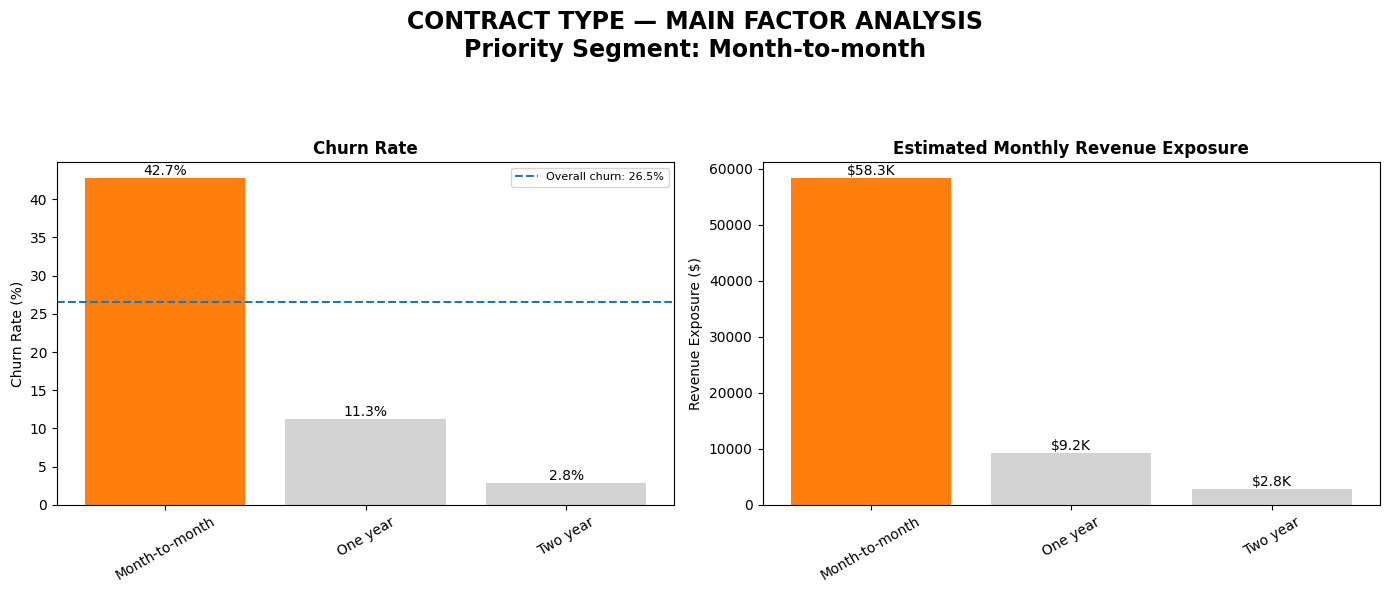

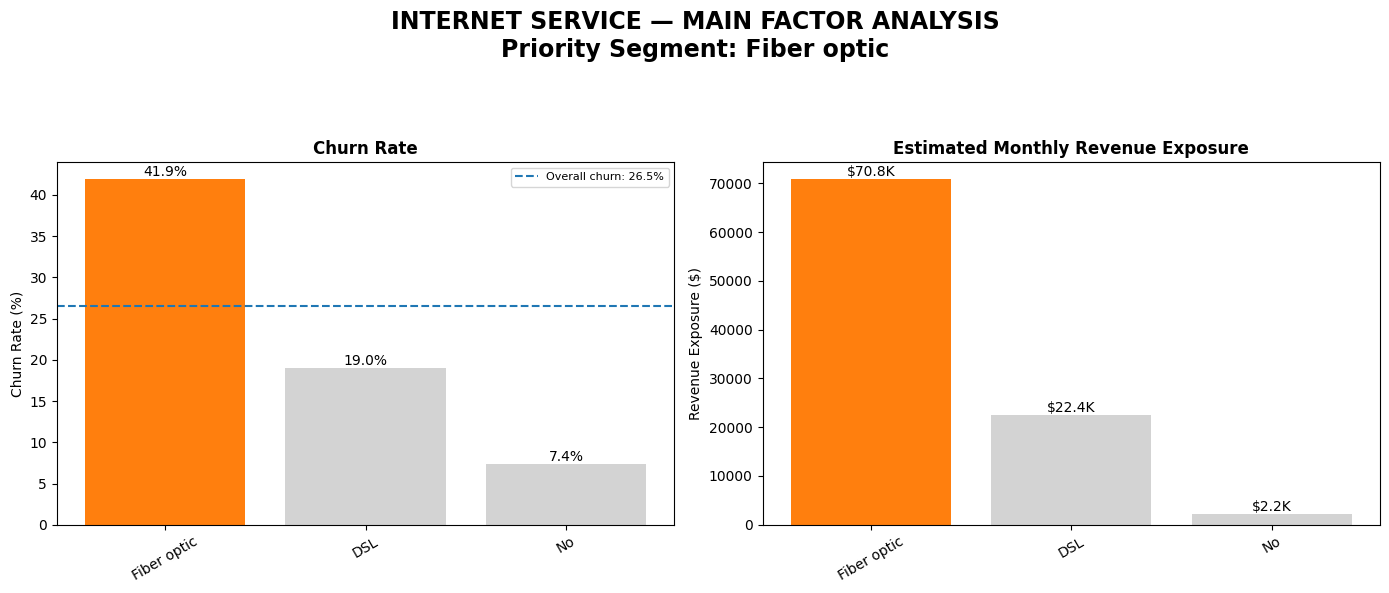

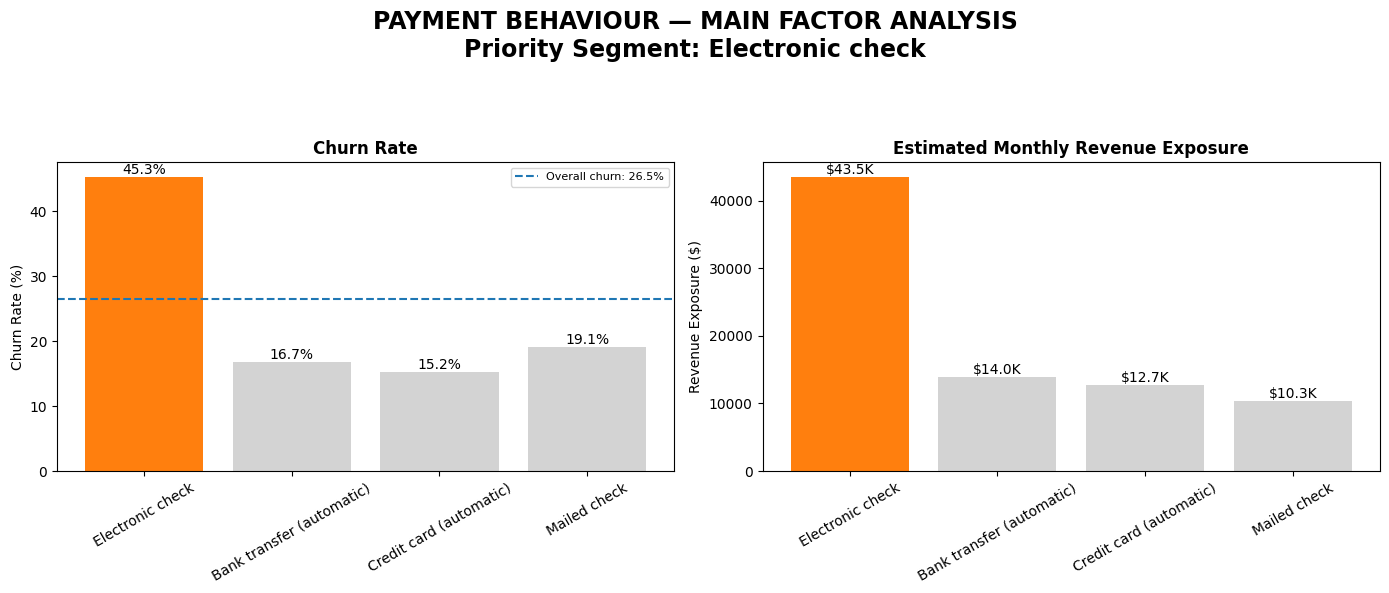

In [15]:
main_factors = [
    ("Contract Type", "contract"),
    ("Internet Service", "internet_service"),
    ("Payment Behaviour", "payment_method")
]

OVERALL_CHURN = 26.5


for factor_name, factor_col in main_factors:

    # Analyze the selected factor
    data = segment_risk_analysis(
        df,
        factor_col
    ).copy()

    # Select the category with the highest potential revenue exposure
    priority_category = data.loc[
        data["estimated_monthly_revenue_exposure"].idxmax(),
        factor_col
    ]

    data = data.sort_values(
        "estimated_monthly_revenue_exposure",
        ascending=False
    ).reset_index(drop=True)

    categories = data[
        factor_col
    ].astype(str)

    # Highlight the priority category
    bar_colors = [
        "tab:orange"
        if category == str(priority_category)
        else "lightgray"
        for category in categories
    ]

    # Create churn and revenue exposure charts
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 6)
    )

    # Churn rate
    ax = axes[0]

    bars = ax.bar(
        categories,
        data["churn_rate"],
        color=bar_colors
    )

    ax.axhline(
        OVERALL_CHURN,
        linestyle="--",
        linewidth=1.5,
        label=f"Overall churn: {OVERALL_CHURN:.1f}%"
    )

    ax.set_title(
        "Churn Rate",
        fontweight="bold"
    )

    ax.set_ylabel(
        "Churn Rate (%)"
    )

    ax.tick_params(
        axis="x",
        rotation=30
    )

    for bar, value in zip(
        bars,
        data["churn_rate"]
    ):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.1f}%",
            ha="center",
            va="bottom"
        )

    ax.legend(fontsize=8)

    # Revenue exposure
    ax = axes[1]

    bars = ax.bar(
        categories,
        data["estimated_monthly_revenue_exposure"],
        color=bar_colors
    )

    ax.set_title(
        "Estimated Monthly Revenue Exposure",
        fontweight="bold"
    )

    ax.set_ylabel(
        "Revenue Exposure ($)"
    )

    ax.tick_params(
        axis="x",
        rotation=30
    )

    for bar, value in zip(
        bars,
        data["estimated_monthly_revenue_exposure"]
    ):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"${value / 1000:.1f}K",
            ha="center",
            va="bottom"
        )


    # Add the factor and priority segment to the chart title
    fig.suptitle(
        f"{factor_name.upper()} — MAIN FACTOR ANALYSIS\n"
        f"Priority Segment: {priority_category}",
        fontsize=17,
        fontweight="bold"
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.90]
    )

    plt.show()

#### 8. Driver Analysis Within Priority Segments

1. **Set the benchmark**Take each priority segment (Month-to-month, Fiber optic, Electronic check) and use its own churn rate as the benchmark.

2. **Examine different angles**: Analyse each priority segment using different customer attributes, one driver at a time.

3. Check each category individually:

    - **Group size**: At least 100 customers.

    - **Churn rate**: Clearly above the segment rate (the 95% confidence interval lies entirely above it).

    - **Actionability**: The company can act on the characteristic. Gender, Senior Citizen, Partner, and Dependents are excluded.

4. **List by revenue exposure**: Rank qualifying subgroups by estimated monthly revenue exposure and show the top three per segment. This highlights where the most revenue is involved, not which driver matters most.

5. **Avoid adding exposure values**: The same customer can appear in subgroups across different drivers, so exposure amounts should not be added together.

In [ ]:
MIN_SEGMENT = 100   # Minimum customers required for comparison
TOP_N = 3           # Number of top drivers shown per priority segment

# Characteristics the company cannot act on (excluded from the driver analysis)
NOT_ACTIONABLE = ["Gender", "Senior Citizen", "Partner", "Dependents"]

# Priority segments identified in the main-factor analysis
priority_segments = [
    ("Month-to-month", "contract", "Month-to-month"),
    ("Fiber optic", "internet_service", "Fiber optic"),
    ("Electronic check", "payment_method", "Electronic check"),
]

def driver_analysis(seg_col, seg_value):

    # Select the priority segment
    seg = df[df[seg_col] == seg_value].copy()

    # Segment churn rate = benchmark
    seg_churn = seg["churn_flag"].mean() * 100

    frames = []

    # Analyze each remaining attribute separately
    for dim_name, col in dimensions.items():

        # Skip the attribute that defines the segment
        if col == seg_col:
            continue

        r = segment_risk_analysis(seg, col).rename(columns={col: "category"})
        r["category"] = r["category"].astype(str)
        r.insert(0, "driver", dim_name)
        frames.append(r)

    out = pd.concat(frames, ignore_index=True)

    # Remove small categories
    out = out[out["total_customers"] >= MIN_SEGMENT].copy()

    # Churn compared with the segment average
    out["above_segment_avg"] = out["churn_rate"] > seg_churn
    out["lift_vs_segment"] = out["churn_rate"] / seg_churn

    # 95% confidence interval for each category's churn rate
    p = out["churn_rate"] / 100
    margin = 1.96 * np.sqrt(p * (1 - p) / out["total_customers"]) * 100
    out["ci_lower"] = out["churn_rate"] - margin
    out["ci_upper"] = out["churn_rate"] + margin
    out["clearly_above_segment_avg"] = out["ci_lower"] > seg_churn

    # Only characteristics the company can act on
    out["actionable"] = ~out["driver"].isin(NOT_ACTIONABLE)

    # Final screening
    out["worth_investigating"] = out["clearly_above_segment_avg"] & out["actionable"]

    return out, seg_churn


# One final table for all priority segments
results = []

for name, col, value in priority_segments:

    table, seg_churn = driver_analysis(col, value)

    selected = table[table["worth_investigating"]].copy()
    selected.insert(0, "priority_segment", name)
    selected["segment_churn_rate"] = seg_churn

    results.append(selected)


deeper_analysis_df = pd.concat(results, ignore_index=True)

deeper_analysis_df = deeper_analysis_df[
    [
        "priority_segment", "driver", "category", "total_customers",
        "churn_rate", "ci_lower", "segment_churn_rate", "lift_vs_segment",
        "estimated_monthly_revenue_exposure",
    ]
].sort_values(
    ["priority_segment", "estimated_monthly_revenue_exposure"],
    ascending=[True, False]
).reset_index(drop=True)

# Top subgroups per priority segment, ranked by estimated exposure
top_subgroups = deeper_analysis_df.groupby("priority_segment").head(TOP_N)

top_subgroups.round(2)

,priority_segment,driver,category,total_customers,churn_rate,ci_lower,segment_churn_rate,lift_vs_segment,estimated_monthly_revenue_exposure
0,Electronic check,Internet Service,Fiber optic,1595,53.23,50.78,45.29,1.18,36569.04
1,Electronic check,Paperless Billing,Yes,1742,49.77,47.42,45.29,1.10,34266.92
2,Electronic check,Online Security,No,1734,53.17,50.82,45.29,1.17,33468.31
10,Fiber optic,Paperless Billing,Yes,2395,44.59,42.60,41.89,1.06,55899.05
11,Fiber optic,Online Security,No,2257,49.36,47.30,41.89,1.18,51032.24
12,Fiber optic,Tech Support,No,2230,49.37,47.29,41.89,1.18,49747.98
21,Month-to-month,Tech Support,No,2680,50.37,48.48,42.71,1.18,46920.66
22,Month-to-month,Online Security,No,2631,51.05,49.14,42.71,1.20,46456.47
23,Month-to-month,Internet Service,Fiber optic,2128,54.61,52.49,42.71,1.28,46254.18


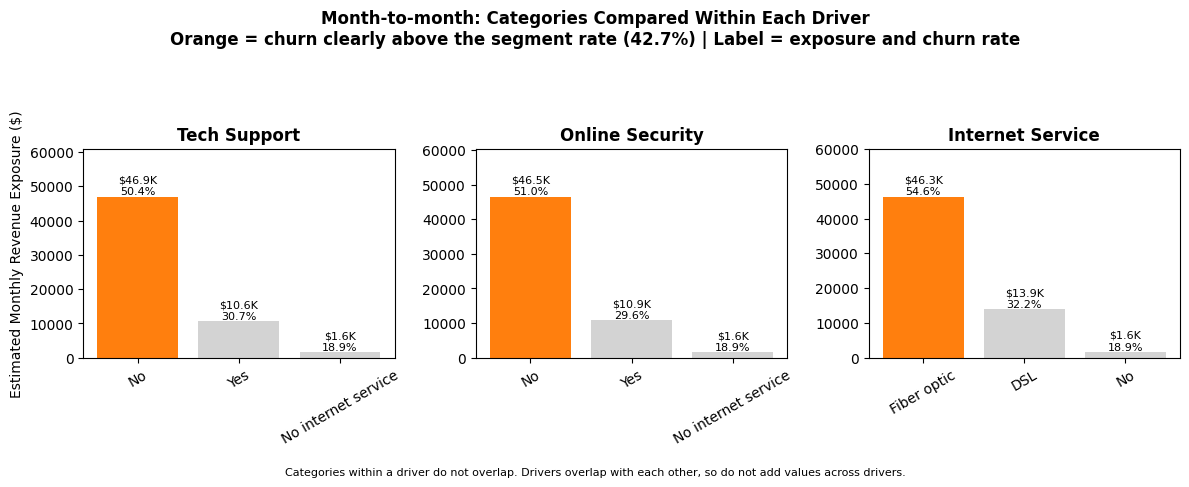

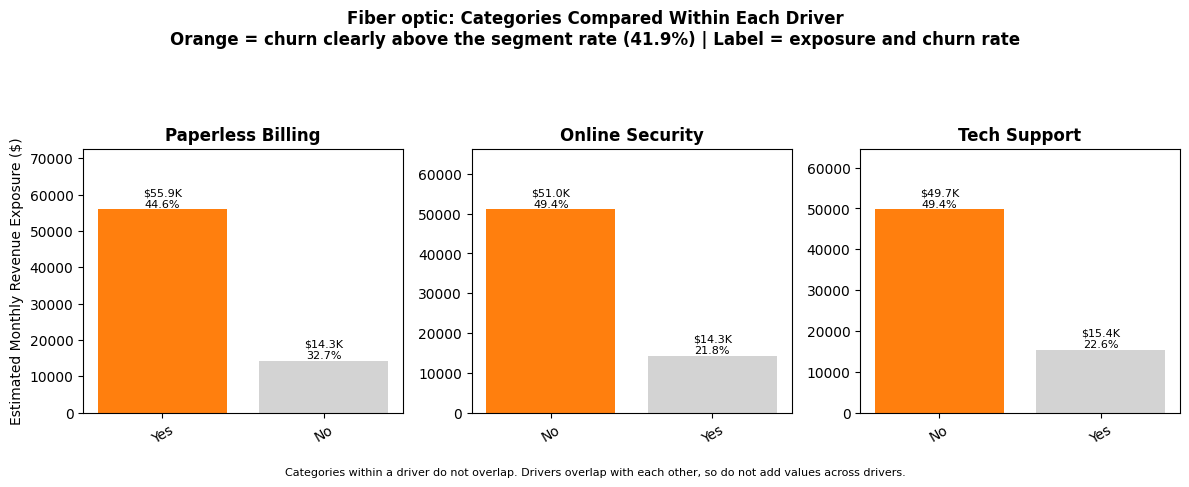

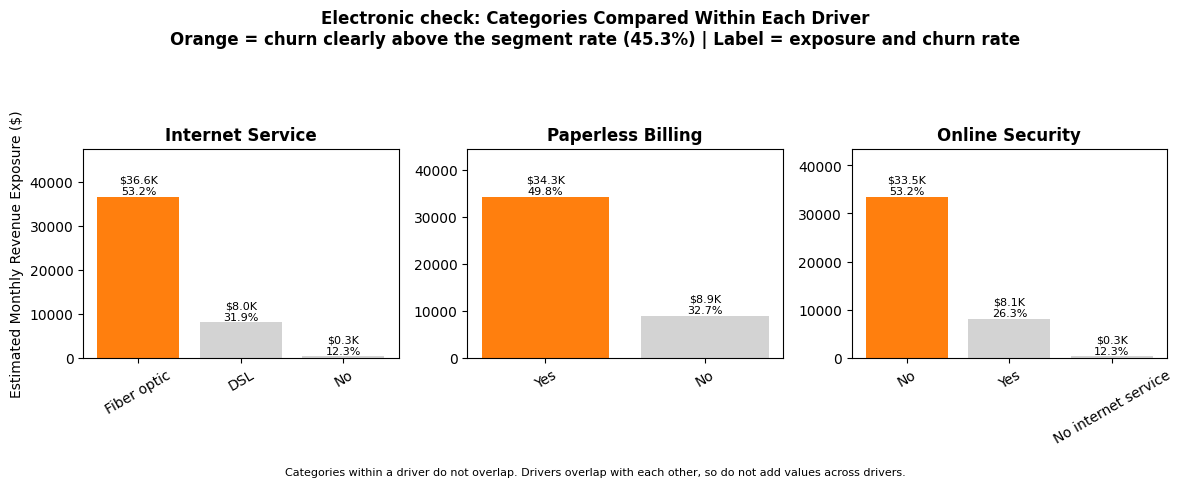

In [21]:
for name, col, value in priority_segments:

    # All categories of every driver inside this segment
    table, seg_churn = driver_analysis(col, value)
    table = table[table["actionable"]]

    # Drivers with at least one qualifying category, ranked by their best exposure
    drivers_shown = (
        deeper_analysis_df[deeper_analysis_df["priority_segment"] == name]
        .groupby("driver")["estimated_monthly_revenue_exposure"].max()
        .sort_values(ascending=False)
        .head(TOP_N)
        .index.tolist()
    )

    if not drivers_shown:
        print(f"No qualifying drivers for {name}")
        continue

    fig, axes = plt.subplots(1, len(drivers_shown), figsize=(4 * len(drivers_shown), 4.8), squeeze=False)

    for ax, driver in zip(axes[0], drivers_shown):

        sub = table[table["driver"] == driver].sort_values(
            "estimated_monthly_revenue_exposure", ascending=False
        )

        colors = ["tab:orange" if flag else "lightgray" for flag in sub["worth_investigating"]]
        bars = ax.bar(sub["category"], sub["estimated_monthly_revenue_exposure"], color=colors)

        for bar, (_, r) in zip(bars, sub.iterrows()):
            ax.text(
                bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"${r['estimated_monthly_revenue_exposure'] / 1000:.1f}K\n{r['churn_rate']:.1f}%",
                ha="center", va="bottom", fontsize=8
            )

        ax.set_title(driver, fontweight="bold")
        ax.tick_params(axis="x", rotation=30)
        ax.set_ylim(0, sub["estimated_monthly_revenue_exposure"].max() * 1.3)

    axes[0][0].set_ylabel("Estimated Monthly Revenue Exposure ($)")

    fig.suptitle(
        f"{name}: Categories Compared Within Each Driver\n"
        f"Orange = churn clearly above the segment rate ({seg_churn:.1f}%) | Label = exposure and churn rate",
        fontweight="bold"
    )
    fig.text(0.5, 0.01,
             "Categories within a driver do not overlap. Drivers overlap with each other, so do not add values across drivers.",
             ha="center", fontsize=8)

    plt.tight_layout(rect=[0, 0.04, 1, 0.88])
    plt.show()

#### 9. Conclusion

Analyzed 7,043 telecom customers: about 1 in 4 (26.5%) had left, and their monthly bills added up to $139.1K.

Of the 17 customer characteristics analysed, three stood out as priority groups based on churn and estimated revenue exposure: Month-to-month contracts (43% churn, ~$58K exposure), Fiber optic internet (42%, ~$70.8K), and Electronic check (45%, ~$43.5K).

Then looked at each priority group from different angles. For each angle, we selected one customer characteristic and compared its subgroups with the overall churn rate of that priority group. The table shows the three subgroups with the highest estimated monthly revenue exposure for each priority group.

| Group | Subgroup inside it | Share who left | Higher than the group by | Monthly revenue at stake |
|---|---|---:|---:|---:|
| **Month-to-month** (43% left) | Without Tech Support | 50% | 1.18× | about $46.9K |
| | Without Online Security | 51% | 1.20× | about $46.5K |
| | On fiber optic internet | 55% | 1.28× | about $46.3K |
| **Fiber optic** (42% left) | Using paperless billing | 45% | 1.06× | about $55.9K |
| | Without Online Security | 49% | 1.18× | about $51.0K |
| | Without Tech Support | 49% | 1.18× | about $49.7K |
| **Electronic check** (45% left) | On fiber optic internet | 53% | 1.18× | about $36.6K |
| | Using paperless billing | 50% | 1.10× | about $34.3K |
| | Without Online Security | 53% | 1.17× | about $33.5K |

Subgroups come from different angles and are listed by revenue involved, not by importance.

**What stands out**

- **Month-to-month:** Customers without Tech Support have the highest estimated revenue exposure ($46.9K/month), while customers using fiber optic internet have the highest churn rate (55%).
- **Fiber optic:** Customers using paperless billing have the highest exposure ($55.9K/month), while customers without Online Security or Tech Support also show higher churn.
- **Electronic check:** Customers using fiber optic internet have the highest exposure ($36.6K/month), with a churn rate of 53%.
- **Common pattern:** Customers without Online Security appear among the top three subgroups in all three segments, while customers without Tech Support appear in two. Both are worth investigating for retention opportunities.

The same customer can appear in more than one row, because the groups and their subgroups overlap, so the revenue amounts are **not added together**. These are patterns associated with higher churn, not proven causes.

#### 10. Recommendations

The following are proposed actions based on the analysis and have not been tested in practice.

| Target group | Recommended action |
|---|---|
| Month-to-month customers using fiber optic internet | Test incentives to encourage switching to longer-term contracts. |
| Month-to-month and Fiber optic customers without Tech Support | Test targeted retention offers for customers who do not use Tech Support. |
| Customers without Online Security across the three priority segments | Test free trials or bundled service offers and measure their effect on retention. |
| Electronic check customers using fiber optic internet | Investigate retention offers, as this subgroup has the highest estimated monthly revenue exposure within the Electronic check segment. |
| Fiber optic customers using paperless billing | Investigate further before targeting this group, as its churn rate is only slightly above the segment average. |

**First step:** Pilot a contract-switching offer for month-to-month customers using fiber optic internet over 2–3 months. Compare their churn with a similar group that does not receive the offer. Expand the offer only if the reduction in churn generates enough additional revenue to justify the cost.